In [1]:
!pip install cmake opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [2]:
import cv2
import dlib

print(cv2.__version__)
print(dlib.__version__)

4.13.0
20.0.0


In [5]:
import os
import cv2            # 이미지 처리의 핵심 (OpenCV)
import matplotlib.pyplot as plt    # 이미지를 화면에 보여주는 도구
import numpy as np    
import dlib            # 얼굴과 코 위치를 찾아주는도구

In [8]:
my_image_path = os.getenv('HOME') + '/work/image.png'
sticker_path = os.getenv('HOME') + '/work/cat-whiskers.png'

In [9]:
img_bgr = cv2.imread(my_image_path)

In [10]:
img_show = img_bgr.copy()

In [11]:
img_sticker = cv2.imread(sticker_path)

In [12]:
print(f"내 사진 크기: {img_bgr.shape}")
print(f"스티커 크기: {img_sticker.shape}")

내 사진 크기: (450, 800, 3)
스티커 크기: (512, 512, 3)


이미지가 잘 불러왔는지 크기를 확인하는겸 겸사겸사 확인해본다

In [13]:
# 1. OpenCV의 BGR 이미지를 Matplotlib에서 쓸 RGB 이미지로 바꿉니다.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

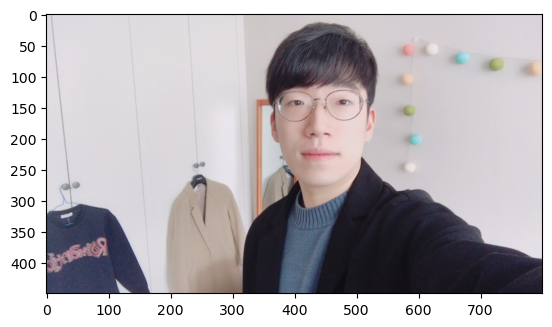

In [14]:
plt.imshow(img_rgb)
plt.show()

## 사진속 얼굴찾기
*호그를 이용해서 사진속 얼굴 좌표를 찾아보자!!

In [15]:
detector_hog = dlib.get_frontal_face_detector()

In [16]:
# 두 번째 파라미터 1은 이미지를 한 번 확대(upsampling)해서 더 작은 얼굴도 잘 찾게 해준다.!
dlib_rects = detector_hog(img_rgb, 1)

In [17]:
print(f"찾은 얼굴 개수: (dlib_rects)개")

찾은 얼굴 개수: (dlib_rects)개


In [18]:
print(f"찾은 얼굴 개수: {len(dlib_rects)}개")

찾은 얼굴 개수: 1개


신기한게 여기서 찾은게 렌으로 출력되는게 신기했다.. 샴쌍둥이면 길이값이 2개일까..

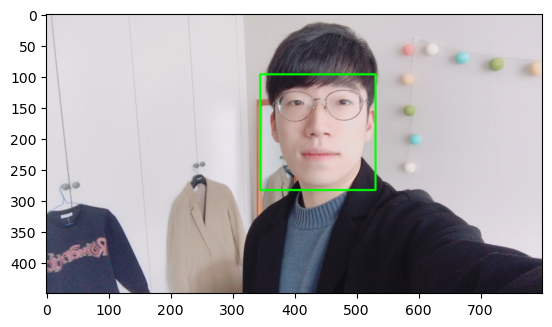

In [19]:
#  찾은 얼굴 영역을 화면에 그려서 확인해자!!
for dlib_rect in dlib_rects:
    # dlib_rect는 얼굴 사각형의 왼쪽 위(l, t)와 오른쪽 아래(r, b) 좌표를 나타낸다.
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()

    # 확인용 복사본 이미지(img_show)에 초록색 사각형을 그려보자 (두께 2)
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

# 결과 출력
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

*찾아 봤는데 얼굴이 여러명일수도 있기때문에 리스트형태로 결과가 나오게 하기위해\
for문으로 코드가 시작된다고 한다.. 역시 이미 선조들이 시행착오를 다 겪어서 나온 코드구나..

## 랜드마크로 고양이수염이 들어갈 코를 추출해보자

In [23]:
model_path = os.getenv('HOME') + '/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2'
landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []

RuntimeError: Unable to open /home/jovyan/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat.bz2

In [25]:
import os
model_path = os.getenv('HOME') + '/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat'

In [26]:
landmark_predictor = dlib.shape_predictor(model_path)

In [27]:
list_landmarks = []

In [32]:
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    # 68개의 점(랜드마크)을 찾아냅니다.

In [33]:
# 찾아낸 점들을 (x, y) 좌표 형태로 리스트에 저장합니다.
list_points = list(map(lambda p: (p.x, p.y), points.parts()))
list_landmarks.append(list_points)

In [35]:
print(f"코 끝 좌표: {list_landmarks[0][30]}")

코 끝 좌표: (437, 182)


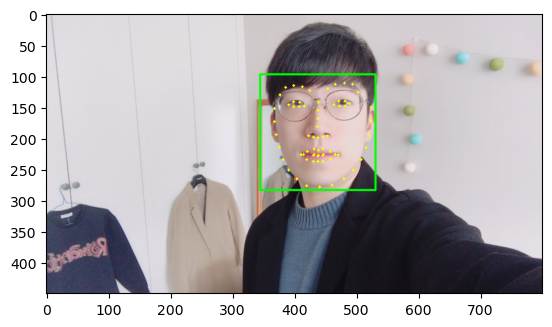

In [37]:
#  모든 점을 이미지 위에 그려서 확인해봅시다.
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1) # 노란색 점

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

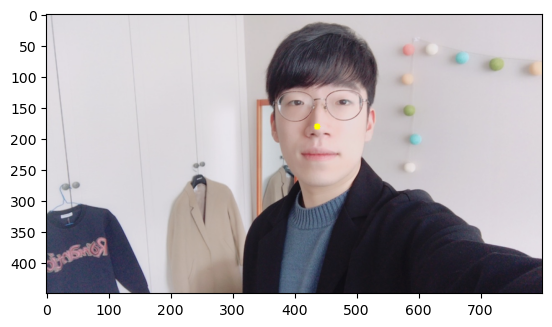

In [83]:
img_show = img_bgr.copy()

#  코 끝 점만 그리기
for landmark in list_landmarks:
    # 30번 점(코 끝)의 x, y 좌표를 가져옵니다.
    x_nose, y_nose = landmark[30]
    
    # 해당 좌표에만 노란색 원을 그립니다.
    # cv2.circle(이미지, 중심좌표, 반지름, 색상(BGR), 두께(-1은 채우기))
    cv2.circle(img_show, (x_nose, y_nose), 5, (0, 255, 255), -1)

# RGB로 변환하여 출력
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

## 고양이 스티커가 들어갈 좌표를 계산해보자

In [84]:
# 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    #  코의 위치를 변수에 담습니다.
    x = landmark[30][0] # 코 끝의 x좌표
    y = landmark[30][1] # 코 끝의 y좌표
    
    #  스티커의 가로(w)와 세로(h) 크기를 얼굴 영역의 가로 길이로 맞춥니다.
    w = h = dlib_rect.width()
    # 스티커를 붙일 시작 위치(왼쪽 위 끝점) 계산
    # 스티커의 '중심'이 코에 오게 하려면, 전체 크기의 절반씩 왼쪽/위로 이동해야 한다.
    refined_x = x - w // 2
    refined_y = (y - h // 2) + 20  # 아래로 갈수록 y가 커지므로, 위로 올리기 위해 빼야된다

In [85]:
print(f"스티커 시작점(Top-Left): ({refined_x}, {refined_y})")
print(f"스티커 크기(w, h): ({w}, {h})")

스티커 시작점(Top-Left): (344, 109)
스티커 크기(w, h): (187, 187)


y값에 - , 1/2 를 하는것은 기존 xy좌표와 다르게 컴퓨터는 예전부터 이미지를 출력할때 왼쪽 상단부터\
출력하던것이 지금까지 내려와서 이미지 표는 y값이 기존 좌표값과는 반대라고 한다.

In [86]:
# 계산된 크기에 맞춰 스티커 이미지를 조절합니다.
img_sticker = cv2.resize(img_sticker, (w, h))

print(f"리사이즈 완료! 현재 스티커 크기: {img_sticker.shape}")

리사이즈 완료! 현재 스티커 크기: (187, 187, 3)


## 사진 밖으로 나가는 부분 처리 (y좌표가 음수일경우)
* 왕관가 다르게 중앙부분의 위치해서 음수가 되지 않을것 같지만 전 노드에서 배운거기때문에\
* 그래도 오류가 날수있으니 좌표를 0으로 맞쳐서 진행해보자

In [87]:
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:] # 잘린 만큼 스티커 왼쪽을 제거
    refined_x = 0

In [88]:
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # 잘린 만큼 스티커 위쪽을 제거
    refined_y = 0 # 시작 좌표를 0으로 고정

In [89]:
print(f"조정된 좌표: ({refined_x}, {refined_y})")

조정된 좌표: (344, 109)


## 고양이 수염 합성하기

In [90]:
# 스티커를 붙일 영역(관심 영역, ROI) 설정
sticker_area = img_show[refined_y:refined_y + img_sticker.shape[0], 
                        refined_x:refined_x + img_sticker.shape[1]]

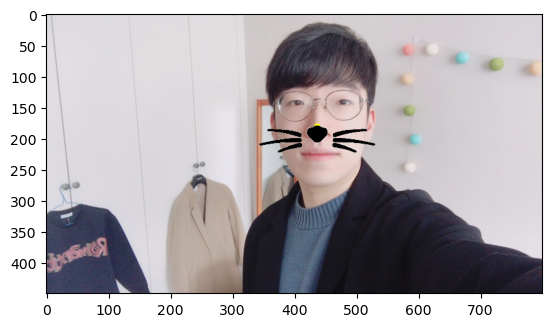

In [91]:
# np.where를 사용해 스티커 픽셀이 255(흰색)인 부분은 원본을 유지하고, 
# 아닌 부분(수염 부분)만 스티커를 적용합니다.
img_show[refined_y:refined_y + img_sticker.shape[0], 
         refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker == 255, sticker_area, img_sticker).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

완성!
이제 다른 여러장의 사진을 넣어서 만들어보자

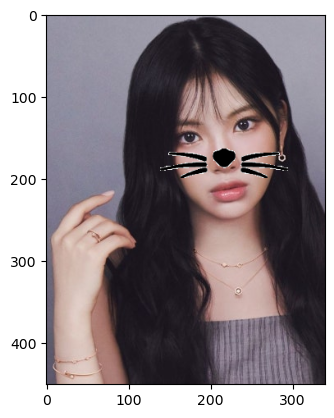

In [93]:
new_image_path = os.getenv('HOME') + '/work/다운로드.jpg'
img_bgr = cv2.imread(new_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

#  얼굴 및 랜드마크 검출 (이전 단계에서 선언한 detector와 predictor 재사용)
dlib_rects = detector_hog(img_rgb, 1)

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    # 코 끝 좌표 (30번)
    x = list_points[30][0]
    y = list_points[30][1]
    
    # 스티커 크기 계산 및 리사이즈
    w = h = dlib_rect.width()
    img_sticker_res = cv2.resize(img_sticker, (w, h)) # 원본 스티커 이미지 사용
    
    # 좌표 계산 
    refined_x = x - w // 2
    refined_y = y - h // 2 # 원하는 만큼 조정
    
    #  예외 처리 (이미지 경계를 벗어날 경우)
    if refined_y < 0:
        img_sticker_res = img_sticker_res[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_res = img_sticker_res[:, -refined_x:]
        refined_x = 0

    #  합성 (ROI 설정 및 np.where)
    sticker_area = img_show[refined_y:refined_y + img_sticker_res.shape[0], 
                            refined_x:refined_x + img_sticker_res.shape[1]]

    img_show[refined_y:refined_y + img_sticker_res.shape[0], 
             refined_x:refined_x + img_sticker_res.shape[1]] = \
        np.where(img_sticker_res == 255, sticker_area, img_sticker_res).astype(np.uint8)

#  결과 출력
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

 스티커사진 y값을 살짝 조정해보자

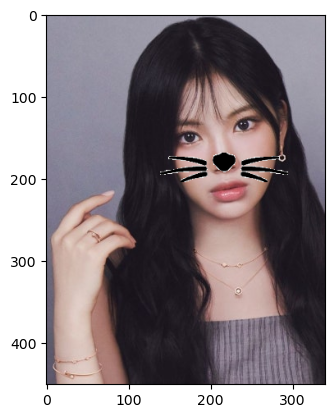

In [95]:
new_image_path = os.getenv('HOME') + '/work/다운로드.jpg'
img_bgr = cv2.imread(new_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

#  얼굴 및 랜드마크 검출 (이전 단계에서 선언한 detector와 predictor 재사용)
dlib_rects = detector_hog(img_rgb, 1)

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    # 코 끝 좌표 (30번)
    x = list_points[30][0]
    y = list_points[30][1]
    
    # 스티커 크기 계산 및 리사이즈
    w = h = dlib_rect.width()
    img_sticker_res = cv2.resize(img_sticker, (w, h)) # 원본 스티커 이미지 사용
    
    # 좌표 계산 
    refined_x = x - w // 2
    refined_y = (y - h // 2)+5 # 원하는 만큼 조정
    
    #  예외 처리 (이미지 경계를 벗어날 경우)
    if refined_y < 0:
        img_sticker_res = img_sticker_res[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_res = img_sticker_res[:, -refined_x:]
        refined_x = 0

    #  합성 (ROI 설정 및 np.where)
    sticker_area = img_show[refined_y:refined_y + img_sticker_res.shape[0], 
                            refined_x:refined_x + img_sticker_res.shape[1]]

    img_show[refined_y:refined_y + img_sticker_res.shape[0], 
             refined_x:refined_x + img_sticker_res.shape[1]] = \
        np.where(img_sticker_res == 255, sticker_area, img_sticker_res).astype(np.uint8)

#  결과 출력
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

1. 얼굴 각도에 따른 영향
현상: '/work/다운로드.jpg'처럼 고개가 살짝 기울어지면, 수염 스티커는 회전하지 않고 가로로 평행하게만 붙는다.

분석: dlib 랜드마크는 기울어진 코의 위치는 잘 찾지만, 스티커 자체에 회전(rotation) 로직이 없다면 수염이 얼굴 각도와 따로 노는 현상이 발생다.

해결 방안: 랜드마크의 눈 위치 등을 이용해 얼굴의 기울기(Angle)를 계산하고, cv2.getRotationMatrix2D 함수로 스티커를 회전시켜 합성해야 된다.



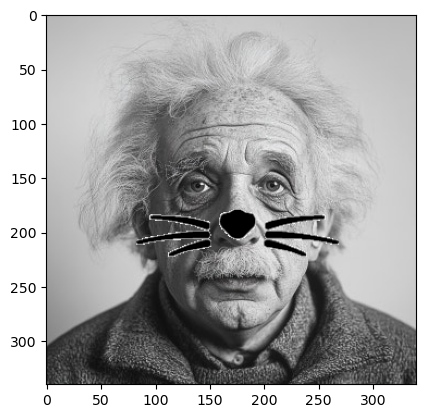

In [102]:
new_image_path = os.getenv('HOME') + '/work/다운로드 (1).jpg'
img_bgr = cv2.imread(new_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

#  얼굴 및 랜드마크 검출 (이전 단계에서 선언한 detector와 predictor 재사용)
dlib_rects = detector_hog(img_rgb, 1)

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    # 코 끝 좌표 (30번)
    x = list_points[30][0]
    y = list_points[30][1]
    
    # 스티커 크기 계산 및 리사이즈
    w = h = dlib_rect.width()
    img_sticker_res = cv2.resize(img_sticker, (w, h)) # 원본 스티커 이미지 사용
    
    # 좌표 계산 
    refined_x = x - w // 2
    refined_y = (y - h // 2)+5 # 원하는 만큼 조정
    
    #  예외 처리 (이미지 경계를 벗어날 경우)
    if refined_y < 0:
        img_sticker_res = img_sticker_res[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_res = img_sticker_res[:, -refined_x:]
        refined_x = 0

    #  합성 (ROI 설정 및 np.where)
    sticker_area = img_show[refined_y:refined_y + img_sticker_res.shape[0], 
                            refined_x:refined_x + img_sticker_res.shape[1]]

    img_show[refined_y:refined_y + img_sticker_res.shape[0], 
             refined_x:refined_x + img_sticker_res.shape[1]] = \
        np.where(img_sticker_res == 255, sticker_area, img_sticker_res).astype(np.uint8)

#  결과 출력
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

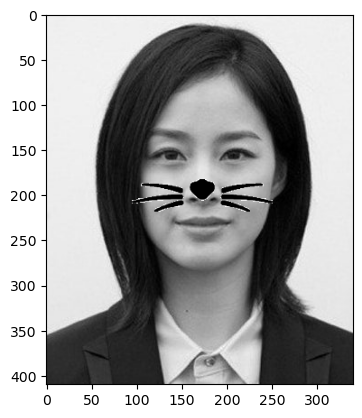

In [99]:
new_image_path = os.getenv('HOME') + '/work/다운로드 (2).jpg'
img_bgr = cv2.imread(new_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

#  얼굴 및 랜드마크 검출 (이전 단계에서 선언한 detector와 predictor 재사용)
dlib_rects = detector_hog(img_rgb, 1)

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    # 코 끝 좌표 (30번)
    x = list_points[30][0]
    y = list_points[30][1]
    
    # 스티커 크기 계산 및 리사이즈
    w = h = dlib_rect.width()
    img_sticker_res = cv2.resize(img_sticker, (w, h)) # 원본 스티커 이미지 사용
    
    # 좌표 계산 
    refined_x = x - w // 2
    refined_y = (y - h // 2)+5 # 원하는 만큼 조정
    
    #  예외 처리 (이미지 경계를 벗어날 경우)
    if refined_y < 0:
        img_sticker_res = img_sticker_res[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_res = img_sticker_res[:, -refined_x:]
        refined_x = 0

    #  합성 (ROI 설정 및 np.where)
    sticker_area = img_show[refined_y:refined_y + img_sticker_res.shape[0], 
                            refined_x:refined_x + img_sticker_res.shape[1]]

    img_show[refined_y:refined_y + img_sticker_res.shape[0], 
             refined_x:refined_x + img_sticker_res.shape[1]] = \
        np.where(img_sticker_res == 255, sticker_area, img_sticker_res).astype(np.uint8)

#  결과 출력
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

이미지 밝기(Lighting)의 영향
현상: 너무 어둡거나 역광인 곳에서 촬영하면 얼굴 검출기(detector_hog)가 얼굴을 아예 찾지 못할 수 있습니다.

분석: HOG 알고리즘은 픽셀의 밝기 차이(Gradient)를 이용하는데, 조명이 균일하지 않으면 이 패턴을 놓치기 쉽습니다.

해결 방안: 이미지 전처리 단계에서 히스토그램 평활화(Histogram Equalization) 등을 통해 명암비를 높여주면 검출률을 올릴 수 있습니다.

#근대 생각보다 흑백사진에서도 얼굴의 코끝을 잘 검출했다...;;

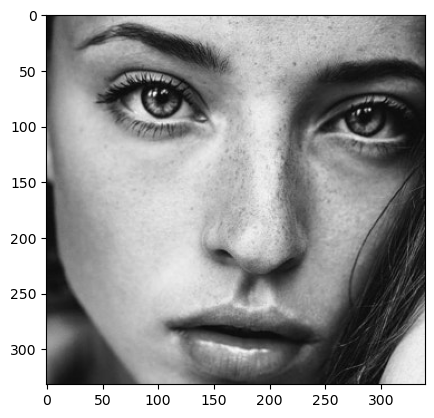

In [104]:
new_image_path = os.getenv('HOME') + '/work/다운로드 (3).jpg'
img_bgr = cv2.imread(new_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

#  얼굴 및 랜드마크 검출 (이전 단계에서 선언한 detector와 predictor 재사용)
dlib_rects = detector_hog(img_rgb, 1)

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    # 코 끝 좌표 (30번)
    x = list_points[30][0]
    y = list_points[30][1]
    
    # 스티커 크기 계산 및 리사이즈
    w = h = dlib_rect.width()
    img_sticker_res = cv2.resize(img_sticker, (w, h)) # 원본 스티커 이미지 사용
    
    # 좌표 계산 
    refined_x = x - w // 2
    refined_y = (y - h // 2)+5 # 원하는 만큼 조정
    
    #  예외 처리 (이미지 경계를 벗어날 경우)
    if refined_y < 0:
        img_sticker_res = img_sticker_res[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_res = img_sticker_res[:, -refined_x:]
        refined_x = 0

    #  합성 (ROI 설정 및 np.where)
    sticker_area = img_show[refined_y:refined_y + img_sticker_res.shape[0], 
                            refined_x:refined_x + img_sticker_res.shape[1]]

    img_show[refined_y:refined_y + img_sticker_res.shape[0], 
             refined_x:refined_x + img_sticker_res.shape[1]] = \
        np.where(img_sticker_res == 255, sticker_area, img_sticker_res).astype(np.uint8)

#  결과 출력
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

이번 사진에서는 고양이 스티커 사진이 출력되지않는 오류가 발견되었다.\
그래서 점심먹고온사이 뭔가 연결이 해제 된거일수 있어서 스티커파일을 다시 불러와보고\
np.where(img_sticker_res == 255, sticker_area, img_sticker_res).astype(np.uint8) << \
이부분이 조건불일치일수 있으므로 조건값을 바꿔가며 오류를 찾아봐야겠다.

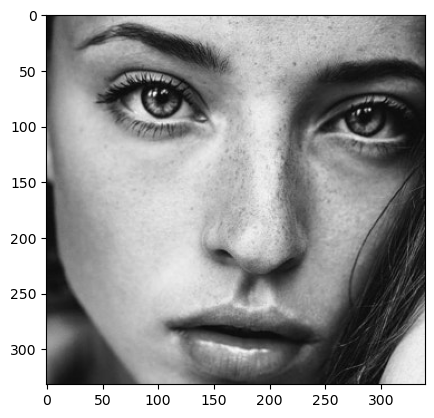

In [139]:
new_image_path = os.getenv('HOME') + '/work/다운로드 (3).jpg'
img_bgr = cv2.imread(new_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

sticker_path = os.getenv('HOME') + '/work/cat-whiskers.png'
img_sticker = cv2.imread(sticker_path)
#  얼굴 및 랜드마크 검출 (이전 단계에서 선언한 detector와 predictor 재사용)
dlib_rects = detector_hog(img_rgb, 1)

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    # 코 끝 좌표 (30번)
    x = list_points[30][0]
    y = list_points[30][1]
    
    # 스티커 크기 계산 및 리사이즈
    w = h = dlib_rect.width()
    img_sticker_res = cv2.resize(img_sticker, (w, h)) # 원본 스티커 이미지 사용
    
    # 좌표 계산 
    refined_x = x - w // 2
    refined_y = (y - h // 2)+5 # 원하는 만큼 조정
    
    #  예외 처리 (이미지 경계를 벗어날 경우)
    if refined_y < 0:
        img_sticker_res = img_sticker_res[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_res = img_sticker_res[:, -refined_x:]
        refined_x = 0

    #  합성 (ROI 설정 및 np.where)
    sticker_area = img_show[refined_y:refined_y + img_sticker_res.shape[0], 
                            refined_x:refined_x + img_sticker_res.shape[1]]

    img_show[refined_y:refined_y + img_sticker_res.shape[0], 
             refined_x:refined_x + img_sticker_res.shape[1]] = \
        np.where(img_sticker_res > 250, sticker_area, img_sticker_res).astype(np.uint8)

#  결과 출력
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

밝기값에 조건을 바꿔줬는데도 안되는거보니 기존 사진들하고 좌표값이 다르게 찍혀있을수도 있다고\
생각이든다. 이사진은 좌표를 다시한번 확인해봐야겠다.

In [111]:
print(f"이미지 크기: {img_show.shape}")
print(f"스티커 시작 좌표: ({refined_x}, {refined_y})")
print(f"스티커 크기: ({img_sticker_res.shape[1]}, {img_sticker_res.shape[0]})")

이미지 크기: (332, 340, 3)
스티커 시작 좌표: (83, 108)
스티커 크기: (186, 186)


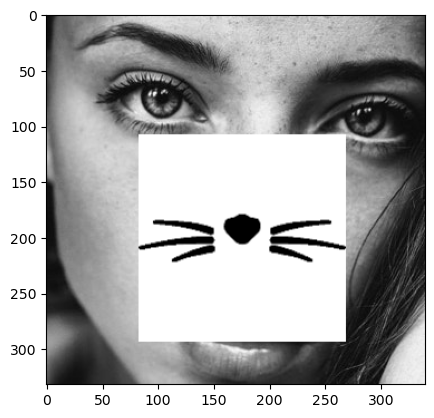

In [112]:
img_show = img_bgr.copy()

# 2. 영역 설정 (에러 방지를 위해 슬라이싱 범위 재확인)
y1, y2 = refined_y, refined_y + img_sticker_res.shape[0]
x1, x2 = refined_x, refined_x + img_sticker_res.shape[1]

# 3. 조건문 없이 강제로 덮어쓰기 (수염 배경이 흰색이어도 그대로 출력됨)
img_show[y1:y2, x1:x2] = img_sticker_res

# 4. 결과 확인
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

혹시나 스티커 가 문제있는지 좌표가 잘 설정되어있지는 않는지 걱정되 강제로 넣어보니 좌표는 잘 설정되있는것 같다\
육안으로는 다른 흑백사진과 비슷한대 컴퓨터가 느끼기에는 미묘하게 밝기차이가 조건값에 안맞았을수도 있을것같다.

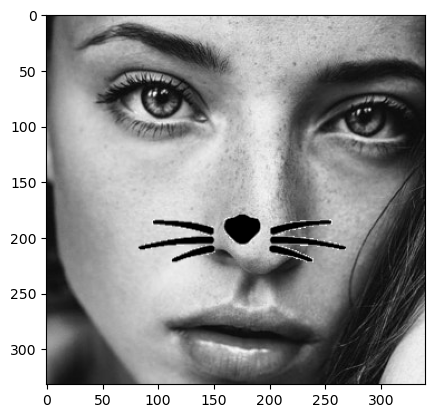

In [113]:
# 1. 도화지 초기화
img_show = img_bgr.copy()

# 2. 스티커가 붙을 원본 영역(관심 영역, ROI) 추출
# x1, x2, y1, y2는 이전 강제 합성 코드에서 쓴 변수를 그대로 사용합니다.
sticker_area = img_show[y1:y2, x1:x2]

# 3. 투명도 처리 및 자연스러운 합성 (핵심!)
# np.where를 사용해 스티커 픽셀 값이 흰색(255)인 부분은 원본(sticker_area)을 유지하고, 
# 아닌 부분(검은색 수염)만 스티커(img_sticker_res)를 적용합니다.
img_show[y1:y2, x1:x2] = \
    np.where(img_sticker_res == 255, sticker_area, img_sticker_res).astype(np.uint8)

# 4. 최종 결과 출력
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

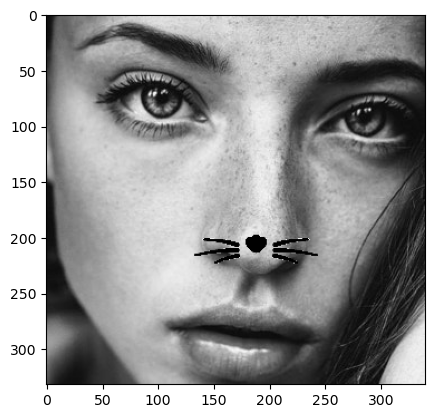

In [133]:
# 1. 도화지 초기화
img_show = img_bgr.copy()

# 2. 스티커 크기 수동 조절 (마음에 안 든다면 비율을 조정하세요)
# 현재 얼굴 사각형의 0.6배 정도로 줄여서 더 자연스럽게 만듭니다.
new_w = int(dlib_rect.width() * 0.6) 
new_h = int(dlib_rect.height() * 0.6)
img_sticker_res = cv2.resize(img_sticker, (new_w, new_h))

# 3. 좌표 재계산 (크기가 바뀌었으므로 다시 계산)
refined_x = x - new_w // 2 + 12
refined_y = y - new_h // 2 + 15 # 15픽셀 정도 아래로

# 4. 합성 영역 추출 (슬라이싱)
sticker_area = img_show[refined_y:refined_y + new_h, refined_x:refined_x + new_w]

# 5. 밝기 기반 합성 (Threshold 적용)
# 스티커의 모든 채널(B, G, R) 중 하나라도 250보다 작으면(어두우면) 수염으로 판단
img_show[refined_y:refined_y + new_h, refined_x:refined_x + new_w] = \
    np.where(img_sticker_res > 250, sticker_area, img_sticker_res).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

수동조정된 스티커 값이 작아 조금더 키워보겠다.

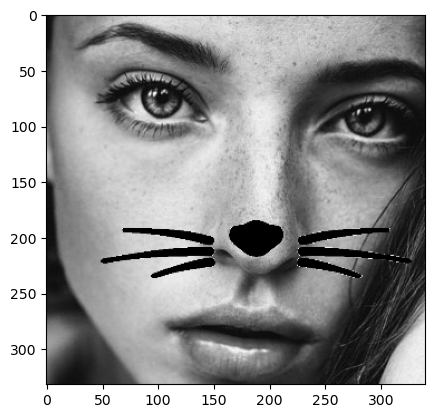

In [141]:
# 1. 도화지 초기화
img_show = img_bgr.copy()

# 2. 스티커 크기 수동 조절 (마음에 안 든다면 비율을 조정하세요)
# 사진의 픽셀에 맞게 최대 조절할수있게 조정 
new_w = int(dlib_rect.width() * 1.5) 
new_h = int(dlib_rect.height() * 1.2)
img_sticker_res = cv2.resize(img_sticker, (new_w, new_h))

# 3. 좌표 재계산 (크기가 바뀌었으므로 다시 계산)
refined_x = x - new_w // 2 + 12
refined_y = y - new_h // 2 + 15 # 15픽셀 정도 아래로

# 4. 합성 영역 추출 (슬라이싱)
sticker_area = img_show[refined_y:refined_y + new_h, refined_x:refined_x + new_w]

# 5. 밝기 기반 합성 (Threshold 적용)
# 스티커의 모든 채널(B, G, R) 중 하나라도 250보다 작으면(어두우면) 수염으로 판단
img_show[refined_y:refined_y + new_h, refined_x:refined_x + new_w] = \
    np.where(img_sticker_res > 250, sticker_area, img_sticker_res).astype(np.uint8)


plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

# 결론 
다른원본 사진들과 다르게 처음에 오류가난 이유는 육안으로는 식별안되는 원본사진의 밝기때문이였고 \
두번째는 클로즈업된 사진의 기존 스티커 사진이 사이즈가 맞지 않는 이유때문이였다.\
그래서 스티커 사진사이즈를 사진에 맞쳐 수동조절해주었더니 제대로 합성된것을 볼수있었다.

####[프로젝트 보고서] 카메라 스티커 앱: 고양이 수염 합성 및 변수 분석
1. 프로젝트 개요
목표: 얼굴 인식 및 랜드마크 검출 기술을 활용하여 사용자 사진에 고양이 수염 스티커를 정확하게 합성함.\
\
핵심 기술: dlib (HOG Detector, 68 Landmarks), OpenCV (Image Processing).\

2. 주요 구현 과정\

*얼굴 검출: HOG 알고리즘을 통해 사진 속 \
*얼굴 영역(Bounding Box)을 추출함\
*랜드마크 추출: 68개 특징점 중 코 끝에 해당하는 30번 인덱스를 기준점으로 설정함\
*좌표 계산: 스티커의 정중앙이 코 끝에 위치하도록 시작점(refined\_x, refined\_$)을 산출함\
*이미지 합성: 원본 이미지와 스티커를 np.where 연산을 통해 투명 배경 처리 후 합성함.\
\
3. 문제점 및 다양한 변수 분석 (핵심 평가 항목)\
- 이미지 밝기에 따른 합성 오류\
  *디지털 이미지에서 "흰색"은 육안으로 구별되지 않는 미세한 밝기 차이(예: 253, 254 등)를 가짐.\
  기존의 엄격한 조건(==255)으로는 이를 배경으로 인식하지 못함.\
  *임계값(Threshold)을 완화하여 250 이상의 값을 모두 배경으로 처리하는 로직을 적용, 합성의 범용성을 높임.\
  \
-클로즈업 사진에서의 크기 및 픽셀 얼굴이 크게 클로즈업된 사진에서 자동조정된 스티커 사진이 출력이 안됨,\
 비율을 조정(1.2, 1.5배 등)할 때 ValueError: shapes could not be broadcast 에러 발생.오차\
*스티커 사진 크기를 직접 수동 조절하여 해결함


4. 회고\
현재 정면 위주의 합성을 넘어, 얼굴의 회전 값을 계산하여 스티커를 회전시키는 로직을 추가한다면 더욱 완성도\
높은 카메라 앱이 될 것으로 기대됨.
  